First 5 rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           5.173850          3.475148           1.334201          0.244986   
1           4.951607          3.503934           1.387964          0.326411   
2           5.226691          3.195993           1.649459          0.171142   
3           5.533060          3.469676           1.622074          0.290324   
4           4.918046          3.487922           1.495820          0.207579   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Mean of each column
sepal length (cm)    5.803147
sepal width (cm)     3.088036
petal length (cm)    3.783488
petal width (cm)     1.170582
dtype: float64

Standard Deviation
sepal length (cm)    0.798919
sepal width (cm)     0.392937
petal length (cm)    1.710681
petal width (cm)     0.737614
dtype: float64

Mean per species
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                               

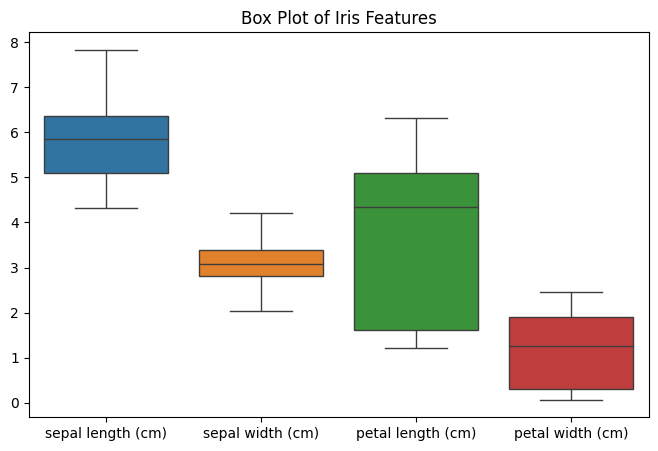

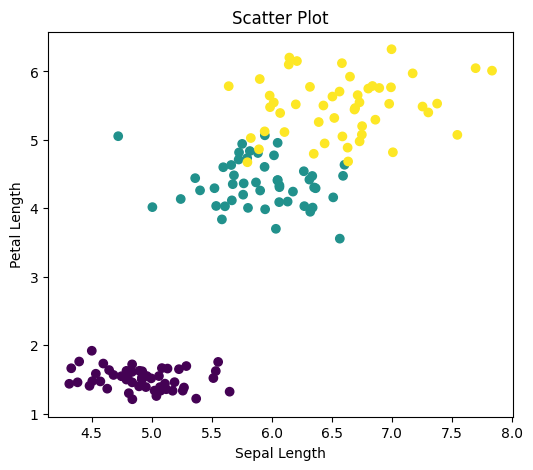

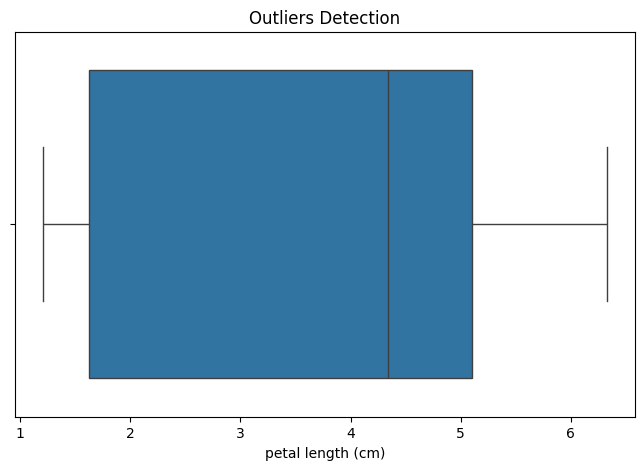

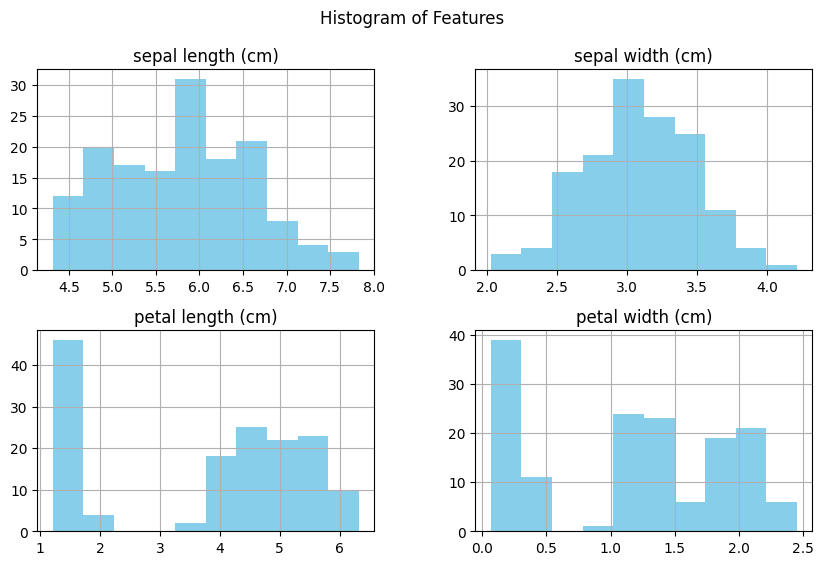

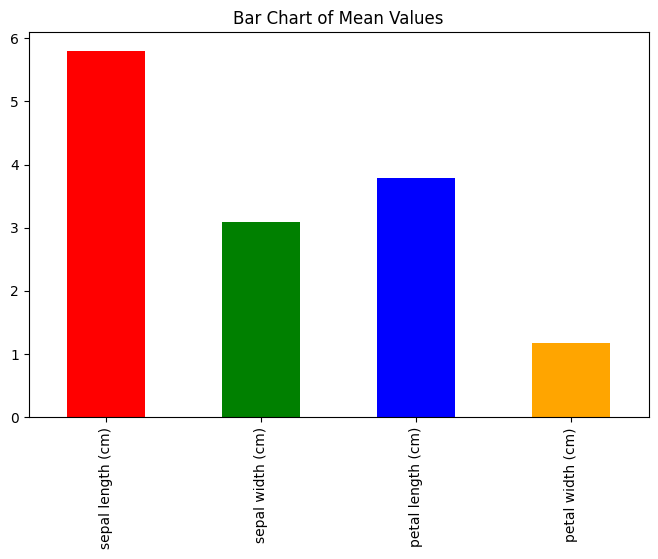

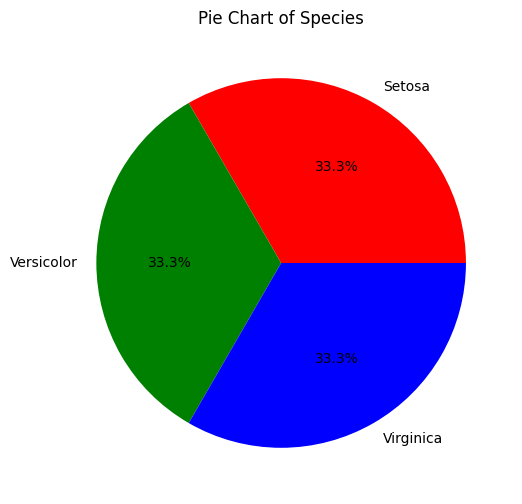

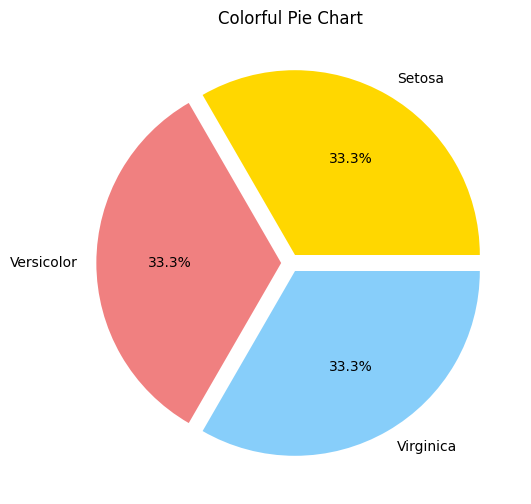

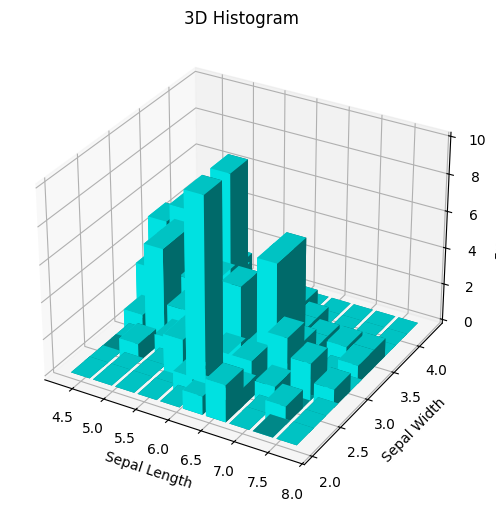


Regression Coefficient: [1.75557404]
Intercept: -6.400400390260239


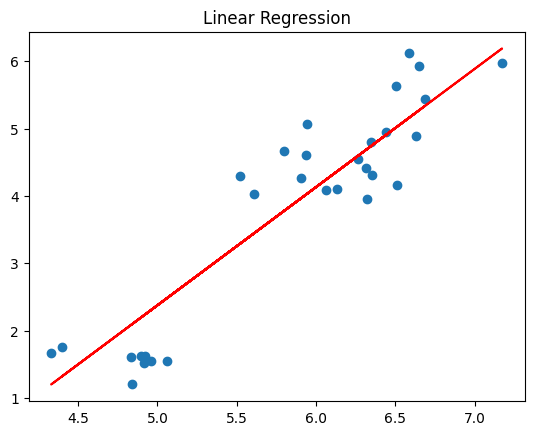


Correlation Matrix
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.436632           0.832927   
sepal width (cm)           -0.436632          1.000000          -0.531257   
petal length (cm)           0.832927         -0.531257           1.000000   
petal width (cm)            0.829592         -0.489794           0.947167   

                   petal width (cm)  
sepal length (cm)          0.829592  
sepal width (cm)          -0.489794  
petal length (cm)          0.947167  
petal width (cm)           1.000000  


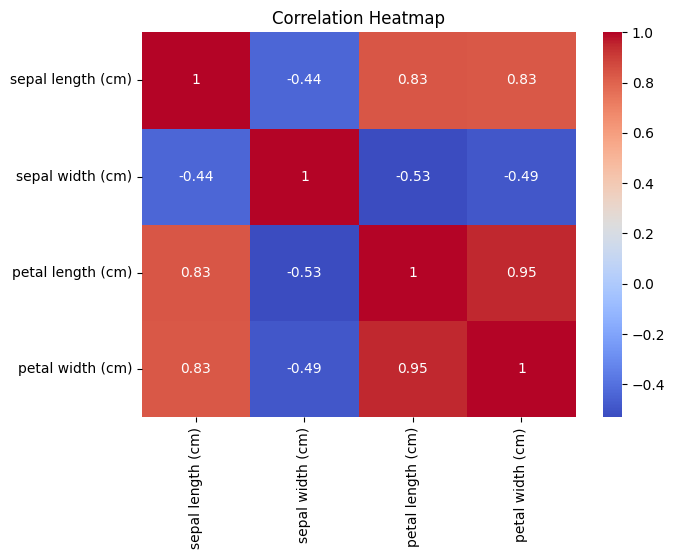


ANOVA Result
F-statistic: 201.17544143451752
P-value: 8.295868002108449e-43


In [1]:
# ============================================
# Iris Dataset Analysis Using CSV
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------
# 1 Load Dataset from CSV as list of lists
# ------------------------------------------------

df = pd.read_csv("iris_sample_dataset.csv")

data_list = df.values.tolist()

print("First 5 rows")
print(df.head())

# ------------------------------------------------
# Mean and Standard Deviation (Overall)
# ------------------------------------------------

print("\nMean of each column")
print(df.iloc[:,:4].mean())

print("\nStandard Deviation")
print(df.iloc[:,:4].std())

# ------------------------------------------------
# Mean and STD per Species
# ------------------------------------------------

print("\nMean per species")
print(df.groupby("species").mean())

print("\nSTD per species")
print(df.groupby("species").std())

# ------------------------------------------------
# a) Data distribution using Box Plot
# ------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(data=df.iloc[:,:4])
plt.title("Box Plot of Iris Features")
plt.show()

# ------------------------------------------------
# Scatter Plot
# ------------------------------------------------

plt.figure(figsize=(6,5))
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'],c=df['species'],cmap='viridis')
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Scatter Plot")
plt.show()

# ------------------------------------------------
# b) Outliers using Box Plot
# ------------------------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x=df['petal length (cm)'])
plt.title("Outliers Detection")
plt.show()

# ------------------------------------------------
# c) Histogram
# ------------------------------------------------

df.iloc[:,:4].hist(figsize=(10,6),color="skyblue")
plt.suptitle("Histogram of Features")
plt.show()

# ------------------------------------------------
# Bar Chart
# ------------------------------------------------

means = df.iloc[:,:4].mean()

plt.figure(figsize=(8,5))
means.plot(kind='bar',color=['red','green','blue','orange'])
plt.title("Bar Chart of Mean Values")
plt.show()

# ------------------------------------------------
# Pie Chart
# ------------------------------------------------

species_counts = df['species'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(species_counts,
        labels=['Setosa','Versicolor','Virginica'],
        autopct='%1.1f%%',
        colors=['red','green','blue'])
plt.title("Pie Chart of Species")
plt.show()

# ------------------------------------------------
# d) Colorful Pie Chart
# ------------------------------------------------

plt.figure(figsize=(6,6))
plt.pie(species_counts,
        labels=['Setosa','Versicolor','Virginica'],
        autopct='%1.1f%%',
        explode=[0.05,0.05,0.05],
        colors=['gold','lightcoral','lightskyblue'])
plt.title("Colorful Pie Chart")
plt.show()

# ------------------------------------------------
# 3D Histogram
# ------------------------------------------------

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

x = df['sepal length (cm)']
y = df['sepal width (cm)']

hist, xedges, yedges = np.histogram2d(x,y,bins=10)

xpos, ypos = np.meshgrid(xedges[:-1],yedges[:-1], indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

dx = dy = 0.3
dz = hist.ravel()

ax.bar3d(xpos,ypos,zpos,dx,dy,dz,color='cyan')

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Frequency')

plt.title("3D Histogram")
plt.show()

# ------------------------------------------------
# 2 Regression Analysis
# ------------------------------------------------

X = df[['sepal length (cm)']]
y = df['petal length (cm)']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("\nRegression Coefficient:",model.coef_)
print("Intercept:",model.intercept_)

plt.scatter(X_test,y_test)
plt.plot(X_test,pred,color="red")
plt.title("Linear Regression")
plt.show()

# ------------------------------------------------
# 3 Correlation Matrix
# ------------------------------------------------

corr = df.iloc[:,:4].corr()

print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------------
# ANOVA (Analysis of Variance)
# ------------------------------------------------

setosa = df[df['species']==0]['sepal length (cm)']
versicolor = df[df['species']==1]['sepal length (cm)']
virginica = df[df['species']==2]['sepal length (cm)']

anova = stats.f_oneway(setosa,versicolor,virginica)

print("\nANOVA Result")
print("F-statistic:",anova.statistic)
print("P-value:",anova.pvalue)